In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.layers import Dense, Input,Dropout
import matplotlib.pyplot as plt
import seaborn as sns
loan_data=pd.read_csv("loan_data.csv")
loan_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
loan_data.duplicated().sum()

np.int64(0)

In [3]:
loan_data.shape

(5789, 122)

In [4]:
loan_data.drop("SK_ID_CURR", axis=1, inplace=True, errors="ignore")
loan_data.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
loan_data.isnull().sum()

,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,779
AMT_REQ_CREDIT_BUREAU_WEEK,779
AMT_REQ_CREDIT_BUREAU_MON,779
AMT_REQ_CREDIT_BUREAU_QRT,779


In [6]:
int_cols=loan_data.select_dtypes(include=['int64']).columns
loan_data[int_cols].isnull().sum()

,0
TARGET,0
CNT_CHILDREN,0
DAYS_BIRTH,0
DAYS_EMPLOYED,0
DAYS_ID_PUBLISH,0
FLAG_MOBIL,0
FLAG_EMP_PHONE,0
FLAG_WORK_PHONE,0
FLAG_CONT_MOBILE,0
FLAG_PHONE,0


In [7]:
float_cols=loan_data.select_dtypes(include=['float64']).columns
for col in float_cols:
    loan_data[col] = loan_data[col].fillna(loan_data[col].median())

In [8]:
loan_data[float_cols].isnull().sum()

,0
AMT_INCOME_TOTAL,0
AMT_CREDIT,0
AMT_ANNUITY,0
AMT_GOODS_PRICE,0
REGION_POPULATION_RELATIVE,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0
AMT_REQ_CREDIT_BUREAU_WEEK,0
AMT_REQ_CREDIT_BUREAU_MON,0
AMT_REQ_CREDIT_BUREAU_QRT,0


In [9]:
cate_cols=loan_data.select_dtypes(include=['object']).columns
loan_data[cate_cols].isnull().sum()

,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
NAME_TYPE_SUITE,22
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
OCCUPATION_TYPE,1795


In [10]:
for col in cate_cols:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

In [11]:
loan_data[cate_cols].isnull().sum()

,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
NAME_TYPE_SUITE,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0
OCCUPATION_TYPE,0


In [12]:
missing = loan_data.isnull().sum()
missing_percent = (missing / len(loan_data)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values(by='Percentage', ascending=False)
missing_df.head(20)

,Missing Values,Percentage
TARGET,0,0.0
NAME_CONTRACT_TYPE,0,0.0
CODE_GENDER,0,0.0
FLAG_OWN_CAR,0,0.0
FLAG_OWN_REALTY,0,0.0
CNT_CHILDREN,0,0.0
AMT_INCOME_TOTAL,0,0.0
AMT_CREDIT,0,0.0
AMT_ANNUITY,0,0.0
AMT_GOODS_PRICE,0,0.0


In [13]:
loan_payer=loan_data["TARGET"].value_counts(normalize=True)*100
print(loan_payer)

TARGET
0    92.261185
1     7.738815
Name: proportion, dtype: float64


In [14]:
value_count=loan_payer=loan_data["TARGET"].value_counts()
print(value_count)

TARGET
0    5341
1     448
Name: count, dtype: int64


In [15]:
loan_data[cate_cols]

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,reg oper account,block of flats,Panel,No
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,reg oper account,block of flats,Panel,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5784,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Sales staff,SUNDAY,Trade: type 3,reg oper account,block of flats,Panel,No
5785,Cash loans,F,N,Y,Family,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers,FRIDAY,Kindergarten,reg oper account,block of flats,"Stone, brick",No
5786,Cash loans,M,Y,N,Unaccompanied,Working,Higher education,Civil marriage,With parents,IT staff,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
5787,Cash loans,F,N,N,Unaccompanied,Pensioner,Lower secondary,Single / not married,House / apartment,Laborers,SUNDAY,XNA,reg oper account,block of flats,Panel,No


In [16]:
dummy_value=pd.get_dummies(loan_data[cate_cols]).astype(int)
dummy_value.head()

,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_F,CODE_GENDER_M,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,1,0,1,0,1,0,1,0,0,1,...,0,1,0,0,0,0,0,0,1,0
2,0,1,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
3,1,0,1,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
4,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0


In [17]:
num_data=loan_data.drop(cate_cols,axis=1)
num_data.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,-1186.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,-4260.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,-9833.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,-4311.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
loan_df=pd.concat([num_data,dummy_value],axis=1)
loan_df.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,...,0,0,0,0,0,0,1,0,1,0
1,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,-1186.0,...,0,1,0,0,0,0,0,0,1,0
2,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,-4260.0,...,0,0,0,0,0,1,0,0,1,0
3,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,-9833.0,...,0,0,0,0,0,1,0,0,1,0
4,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,-4311.0,...,0,0,0,0,0,1,0,0,1,0


In [19]:
x = loan_df.drop('TARGET', axis=1)
y = loan_df['TARGET']
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

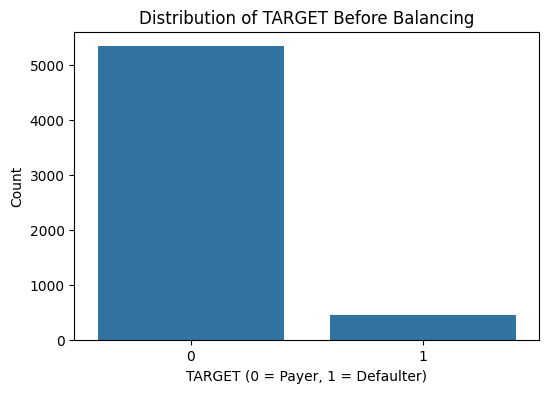

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=loan_df)
plt.title("Distribution of TARGET Before Balancing")
plt.xlabel("TARGET (0 = Payer, 1 = Defaulter)")
plt.ylabel("Count")
plt.show()

In [22]:
y_train.value_counts()

,count
TARGET,
0,4273
1,4273


In [26]:
def model_build():
  model=Sequential([
      Input(shape=(x_train.shape[1],)),
      Dense(128,activation="relu"),
      Dense(64,activation="relu"),
      Dense(32,activation="relu"),
      Dense(16,activation="relu"),
      Dropout(0.3),
      Dense(1,activation="sigmoid")
  ])
  model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc")
])
  return model

In [27]:
model=model_build()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        30,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,601 (162.50 KB)

 Trainable params: 41,601 (162.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=10)

In [30]:
history=model.fit(x_train,y_train,epochs=50,batch_size=32,validation_split=0.2, callbacks=early_stopping)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8738 - auc: 0.9324 - loss: 0.3201 - precision: 0.9208 - recall: 0.7257 - val_accuracy: 0.9906 - val_auc: 0.0000e+00 - val_loss: 0.0386 - val_precision: 1.0000 - val_recall: 0.9906
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9451 - auc: 0.9705 - loss: 0.1678 - precision: 0.9769 - recall: 0.8744 - val_accuracy: 0.9959 - val_auc: 0.0000e+00 - val_loss: 0.0138 - val_precision: 1.0000 - val_recall: 0.9959
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9517 - auc: 0.9796 - loss: 0.1410 - precision: 0.9786 - recall: 0.8908 - val_accuracy: 0.9971 - val_auc: 0.0000e+00 - val_loss: 0.0067 - val_precision: 1.0000 - val_recall: 0.9971
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9606 - auc: 0.9869 - loss: 0.1137 - precision: 0.9799 - recall: 0.9138 - val_accuracy: 0.9982 - val_auc: 0.0000e+00 - val_loss: 0.0036 - val_precision: 1.0000 - val_recall: 0.9982
Epoch 5/50
214

In [31]:
hist=pd.DataFrame(history.history)
hist

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.873757,0.932379,0.320086,0.920792,0.725712,0.990643,0.0,0.038555,1.0,0.990643
1,0.945143,0.970476,0.167796,0.976896,0.874366,0.995906,0.0,0.013818,1.0,0.995906
2,0.951726,0.979604,0.140972,0.978568,0.890753,0.997076,0.0,0.006661,1.0,0.997076
3,0.960649,0.986856,0.113703,0.979916,0.913773,0.998246,0.0,0.003553,1.0,0.998246
4,0.968110,0.991824,0.092544,0.984704,0.929380,0.999415,0.0,0.001495,1.0,0.999415
5,0.974839,0.995399,0.070345,0.986965,0.945377,0.998830,0.0,0.002854,1.0,0.998830
6,0.979228,0.996877,0.060196,0.986731,0.957472,0.997661,0.0,0.006145,1.0,0.997661
7,0.981276,0.996875,0.054097,0.984867,0.964885,0.999415,0.0,0.001605,1.0,0.999415
8,0.984933,0.998220,0.043933,0.986551,0.973078,0.998830,0.0,0.002504,1.0,0.998830
9,0.988444,0.998176,0.037002,0.989748,0.979321,0.998830,0.0,0.002433,1.0,0.998830


In [40]:
from sklearn.metrics import recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
y_pred=model.predict(x_test)

y_pred=(y_pred>0.5).astype(int)
recall=recall_score(y_test,y_pred)
print("Recall:",recall)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Recall: 0.05555555555555555


In [41]:
conf_mat=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[1005   63]
 [  85    5]]


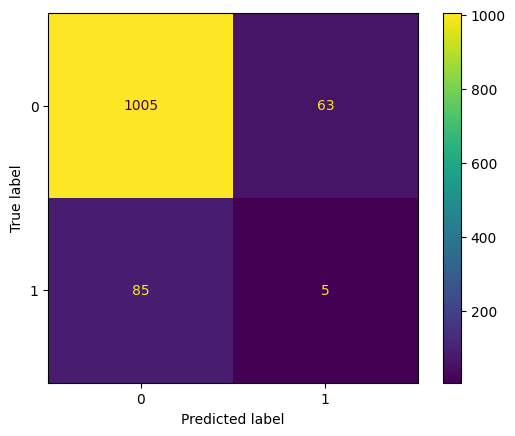

In [42]:
conf_plot=ConfusionMatrixDisplay(confusion_matrix=conf_mat)
conf_plot.plot()
plt.show()

In [43]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("F1 Score:",f1)

Accuracy: 0.8721934369602763
Precision: 0.07352941176470588
F1 Score: 0.06329113924050633


In [44]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_prob = model.predict(x_test).ravel()
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", auc)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ROC-AUC: 0.5748231377444861


Text(0.5, 1.0, 'ROC Curve')

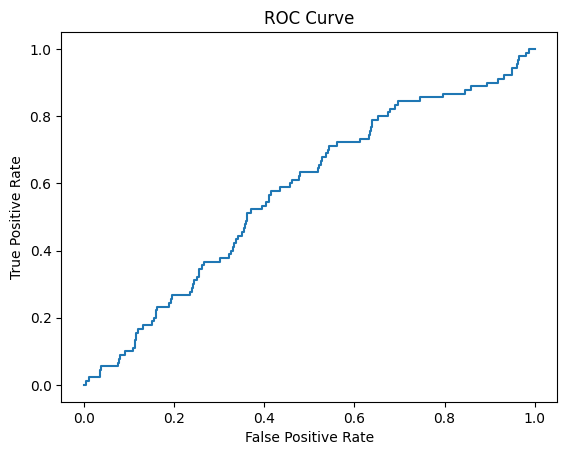

In [45]:
roc_curve=roc_curve(y_test,y_pred_prob)
plt.plot(roc_curve[0],roc_curve[1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")